## NASCON STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

nascon=pd.read_csv('../stock_data/nascon.csv') ## so it can be small letter. This is cool.
nascon=nascon.drop(columns=['high_price','low_price'])
nascon.rename(columns={'trade_date':'date'},inplace=True)
nascon['date']=pd.to_datetime(nascon['date'])
nascon['month']=nascon['date'].dt.month
nascon['quarter']=nascon['date'].dt.quarter
nascon['year']=nascon['date'].dt.year

nascon

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42797,NASCON,2017-01-03,8.5,8.5,19000,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43357,NASCON,2017-01-04,8.5,8.5,41612,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43467,NASCON,2017-01-05,8.5,8.5,42525,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43577,NASCON,2017-01-06,8.5,8.5,9475,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43667,NASCON,2017-01-09,8.5,8.5,4108,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298101,NASCON,2026-07-13,180.0,180.0,685355,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298539,NASCON,2026-07-14,180.0,180.0,253609,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298977,NASCON,2026-07-15,180.0,180.0,478341,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299415,NASCON,2026-07-16,180.0,180.0,853890,2026-07-16T15:10:03.113936+00:00,7,3,2026


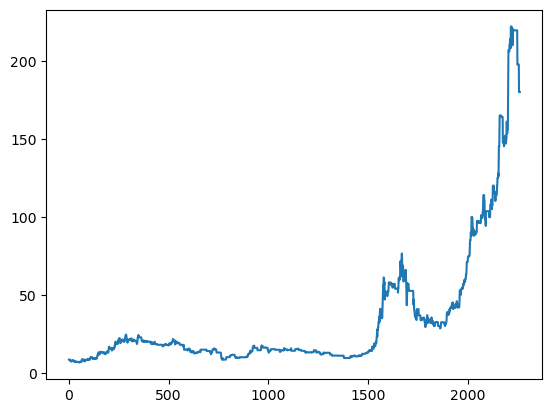

In [2]:
import matplotlib.pyplot as plt

plt.plot(nascon['close_price'])
plt.show()

In [3]:
nascon_end_month_df = (
    nascon
    .sort_values("date")
    .groupby(nascon["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

nascon_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45367,NASCON,2017-01-31,7.83,7.83,155615,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47188,NASCON,2017-02-28,7.00,7.00,34500,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49304,NASCON,2017-03-31,7.10,7.10,50548,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51132,NASCON,2017-04-28,8.49,8.49,3029641,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53054,NASCON,2017-05-31,8.50,8.50,227191,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35338,NASCON,2026-03-31,152.00,152.00,594427,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281164,NASCON,2026-04-30,210.00,210.00,2755278,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284230,NASCON,2026-05-29,220.00,220.00,479566,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294158,NASCON,2026-06-30,219.50,219.50,506209,2026-06-30T15:10:03.08168+00:00,6,2,2026


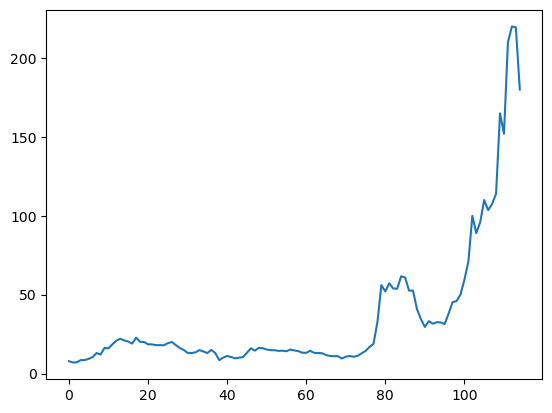

In [4]:
plt.plot(nascon_end_month_df['close_price'])
plt.show()

In [5]:
nascon_end_month_df['returns']=nascon_end_month_df['close_price'].pct_change()*100
nascon_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45367,NASCON,2017-01-31,7.83,7.83,155615,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47188,NASCON,2017-02-28,7.00,7.00,34500,2026-04-08T02:44:45.006295+00:00,2,1,2017,-10.600255
2,49304,NASCON,2017-03-31,7.10,7.10,50548,2026-04-08T02:45:42.281198+00:00,3,1,2017,1.428571
3,51132,NASCON,2017-04-28,8.49,8.49,3029641,2026-04-08T02:51:55.619599+00:00,4,2,2017,19.577465
4,53054,NASCON,2017-05-31,8.50,8.50,227191,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.117786
...,...,...,...,...,...,...,...,...,...,...,...
110,35338,NASCON,2026-03-31,152.00,152.00,594427,2026-03-31T15:00:02.085058+00:00,3,1,2026,-7.850864
111,281164,NASCON,2026-04-30,210.00,210.00,2755278,2026-04-30T15:00:02.170664+00:00,4,2,2026,38.157895
112,284230,NASCON,2026-05-29,220.00,220.00,479566,2026-05-29T15:00:02.455558+00:00,5,2,2026,4.761905
113,294158,NASCON,2026-06-30,219.50,219.50,506209,2026-06-30T15:10:03.08168+00:00,6,2,2026,-0.227273


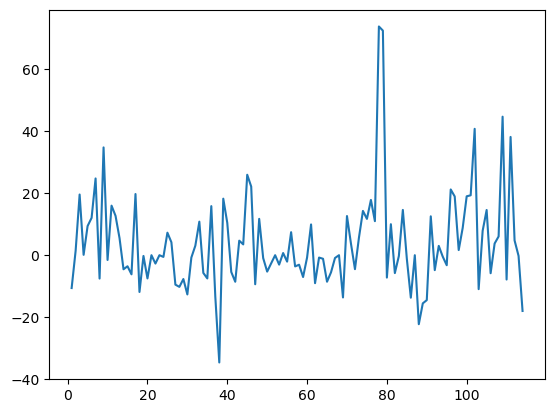

In [6]:
plt.plot(nascon_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(nascon_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-8.534724951413265, 1.0152456784473635e-13, 0, 113, {'1%': -3.489589552580676, '5%': -2.887477210140433, '10%': -2.580604145195395}, 836.2434061922255)
stationary


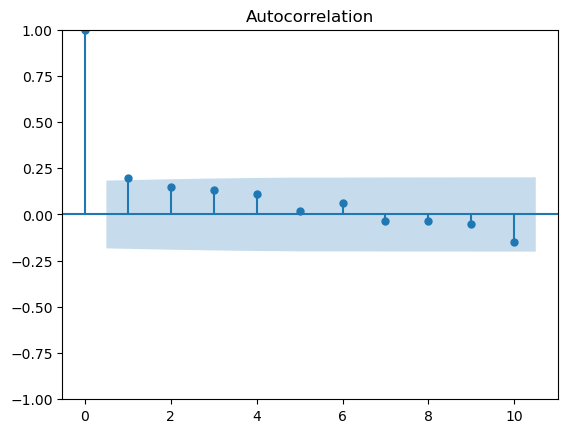

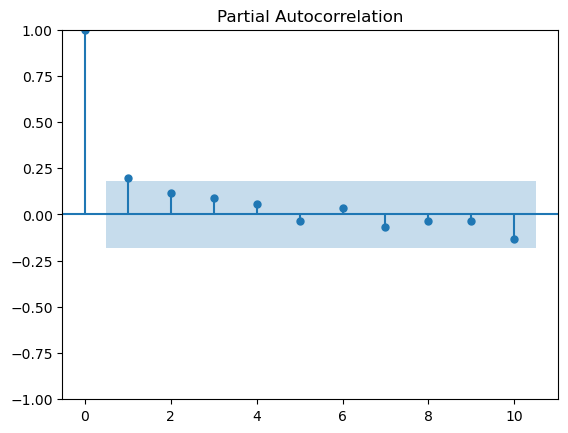

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(nascon_end_month_df['returns'].dropna(), lags=10)
plot_pacf(nascon_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=nascon_end_month_df['close_price'][:-10]
test=nascon_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -12.11405376393259]
[0, 0, 0, 0, 0, 1, -9.600275655341024]
[0, 0, 0, 0, 0, 2, -6.331486882342284]
[0, 0, 0, 0, 1, 0, -5.201589242229928]
[0, 0, 0, 0, 1, 1, -5.630775736788397]
[0, 0, 0, 0, 1, 2, -3.384936151595376]
[0, 0, 0, 0, 2, 0, -5.241149639160951]
[0, 0, 0, 0, 2, 1, -4.659839400312896]
[0, 0, 0, 0, 2, 2, -2.753972594048794]
[0, 0, 0, 1, 0, 0, -6.135854551886309]
[0, 0, 0, 1, 0, 1, -6.244258214444385]
[0, 0, 0, 1, 0, 2, -4.104388239277028]
[0, 0, 0, 1, 1, 0, -5.436509208061618]
[0, 0, 0, 1, 1, 1, -5.039828523423853]
[0, 0, 0, 1, 1, 2, -3.419752679983982]
[0, 0, 0, 1, 2, 0, -2.650140217321066]
[0, 0, 0, 1, 2, 1, -3.120533843905619]
[0, 0, 0, 1, 2, 2, -2.007912525088319]
[0, 0, 0, 2, 0, 0, -5.978880713585926]
[0, 0, 0, 2, 0, 1, -5.606017714871058]
[0, 0, 0, 2, 0, 2, -4.055209787253673]
[0, 0, 0, 2, 1, 0, -4.338145642625763]
[0, 0, 0, 2, 1, 1, -4.210643510179842]
[0, 0, 0, 2, 1, 2, -3.4108678260297536]
[0, 0, 0, 2, 2, 0, -2.9866981633789087]
[0, 0, 0, 2, 2, 1, -2.8

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
726,2,2,2,2,2,0,-204691.842414
0,0,0,0,0,0,0,-12.114054
27,0,0,1,0,0,0,-11.657335
54,0,0,2,0,0,0,-11.167603
1,0,0,0,0,0,1,-9.600276
...,...,...,...,...,...,...,...
219,0,2,2,0,1,0,0.621571
183,0,2,0,2,1,0,0.621803
204,0,2,1,1,2,0,0.622194
170,0,2,0,0,2,2,0.636172


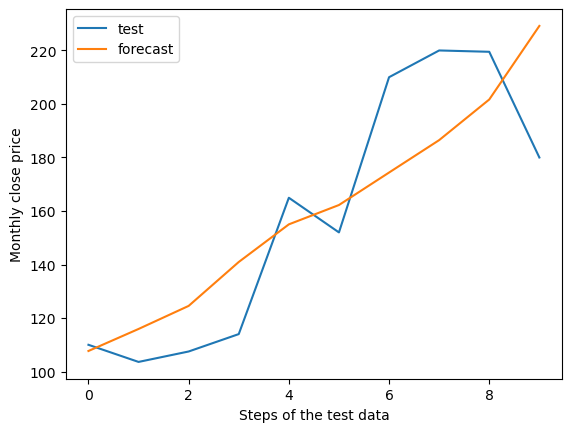

r2_score:  0.6849899621396107
rmse:  25.503534597602105
description:  count    115.000000
mean      35.497043
std       44.365247
min        7.000000
25%       13.000000
50%       16.200000
75%       36.250000
max      220.000000
Name: close_price, dtype: float64


In [12]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=nascon_end_month_df['close_price'][:-10]
y_test=nascon_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,2,0), 
seasonal_order=(1,1,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', nascon_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [7]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=nascon_end_month_df['returns'].dropna()[:-10]
test=nascon_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.1824933664634607]
[0, 0, 0, 0, 0, 1, -0.23406227134177016]
[0, 0, 0, 0, 0, 2, -0.23465277056308476]
[0, 0, 0, 0, 1, 0, -0.7330175706473687]
[0, 0, 0, 0, 1, 1, -0.06889669966034484]
[0, 0, 0, 0, 1, 2, -0.112410082662598]
[0, 0, 0, 0, 2, 0, -5.014067766005114]
[0, 0, 0, 0, 2, 1, -0.9248883661927629]
[0, 0, 0, 0, 2, 2, -0.6239314887800298]
[0, 0, 0, 1, 0, 0, -0.24750928173948883]
[0, 0, 0, 1, 0, 1, -0.17740148014467394]
[0, 0, 0, 1, 0, 2, -0.23514513398302328]
[0, 0, 0, 1, 1, 0, -0.027313531330882546]
[0, 0, 0, 1, 1, 1, -0.1035986849326398]
[0, 0, 0, 1, 1, 2, -0.07214397013456586]
[0, 0, 0, 1, 2, 0, 0.0688716252162258]
[0, 0, 0, 1, 2, 1, -0.11657052006671376]
[0, 0, 0, 1, 2, 2, -0.5876944239054069]
[0, 0, 0, 2, 0, 0, -0.2224089579101023]
[0, 0, 0, 2, 0, 1, -0.22667009658456405]
[0, 0, 0, 2, 0, 2, -0.17809885353717103]
[0, 0, 0, 2, 1, 0, -0.5927290143112693]
[0, 0, 0, 2, 1, 1, -0.07289958944888553]
[0, 0, 0, 2, 1, 2, -0.044012759323216466]
[0, 0, 0, 2, 2, 0, -0.574128

In [8]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
186,0,2,0,2,2,0,-771.425524
177,0,2,0,1,2,0,-594.087037
174,0,2,0,1,1,0,-511.586917
178,0,2,0,1,2,1,-473.633706
187,0,2,0,2,2,1,-356.558197
...,...,...,...,...,...,...,...
577,2,1,0,1,0,2,0.119664
691,2,2,1,2,0,1,0.122642
692,2,2,1,2,0,2,0.127335
683,2,2,1,1,0,2,0.127554


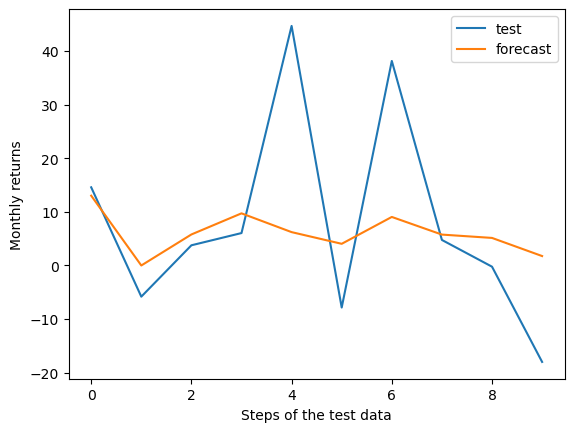

r2_score:  0.16341460328302948
rmse:  17.15328466509374
description:  count    114.000000
mean       3.844311
std       15.755943
min      -34.615385
25%       -5.675908
50%        0.000000
75%       10.939645
max       73.796791
Name: returns, dtype: float64


In [9]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=nascon_end_month_df['returns'].dropna()[:-10]
y_test=nascon_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,1,0), 
seasonal_order=(2,0,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', nascon_end_month_df.returns.dropna().describe())

Very horrible. We will work with close_price
